In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
test_data = pd.read_csv('/test.csv')

In [14]:
df = pd.DataFrame(test_data)
print(df)

     PassengerId  Pclass                                          Name  \
0            892       3                              Kelly, Mr. James   
1            893       3              Wilkes, Mrs. James (Ellen Needs)   
2            894       2                     Myles, Mr. Thomas Francis   
3            895       3                              Wirz, Mr. Albert   
4            896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..           ...     ...                                           ...   
413         1305       3                            Spector, Mr. Woolf   
414         1306       1                  Oliva y Ocana, Dona. Fermina   
415         1307       3                  Saether, Mr. Simon Sivertsen   
416         1308       3                           Ware, Mr. Frederick   
417         1309       3                      Peter, Master. Michael J   

        Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarked  
0      male  34.5      0      0 

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [16]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [18]:
# Dropping unique identifiers which cannot predict survival status
df = df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [19]:
# Normalization of non-integer-valued categories
# Binary encoding of Sex category, mapping 1 to male and 0 to female
df['Sex'] = df['Sex'].map({
    'male':1,
    'female':0
})

# One-hot encoding of the Embarked category being a multi-valued category
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

In [20]:
print(df)

     Pclass  Sex   Age  SibSp  Parch      Fare  Embarked_C  Embarked_Q  \
0         3    1  34.5      0      0    7.8292           0           1   
1         3    0  47.0      1      0    7.0000           0           0   
2         2    1  62.0      0      0    9.6875           0           1   
3         3    1  27.0      0      0    8.6625           0           0   
4         3    0  22.0      1      1   12.2875           0           0   
..      ...  ...   ...    ...    ...       ...         ...         ...   
413       3    1   NaN      0      0    8.0500           0           0   
414       1    0  39.0      0      0  108.9000           1           0   
415       3    1  38.5      0      0    7.2500           0           0   
416       3    1   NaN      0      0    8.0500           0           0   
417       3    1   NaN      1      1   22.3583           1           0   

     Embarked_S  
0             0  
1             1  
2             0  
3             1  
4             1  
.. 

In [24]:
# Checking for missing values in the dataset
df.isna().sum()

,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked_C,0
Embarked_Q,0
Embarked_S,0


In [23]:

# Checking the % of missing values in the column
(df.isna().sum()/len(df))*100

,0
Pclass,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Fare,0.239234
Embarked_C,0.000000
Embarked_Q,0.000000
Embarked_S,0.000000


81    67.0
96    76.0
Name: Age, dtype: float64


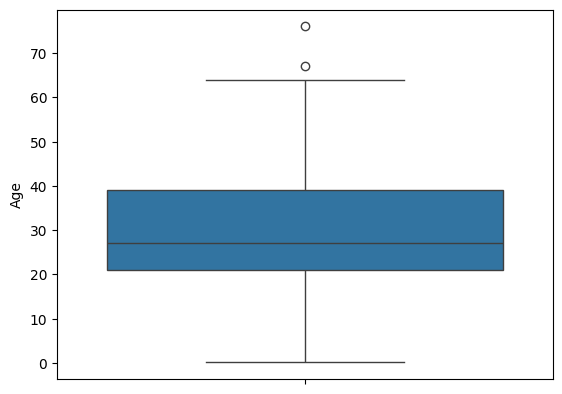

In [31]:
    # Checking for outliers in Age category
    # Significant amount of outliers are present
    Q1 = df['Age'].quantile(0.25)
    Q3 = df['Age'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    fare_outliers = df[
        (df['Age'] < lower) |
        (df['Age'] > upper)
    ]
    print(fare_outliers['Age'])
    sns.boxplot(y='Age',data=df)
    plt.show()

<Axes: xlabel='Age', ylabel='Count'>

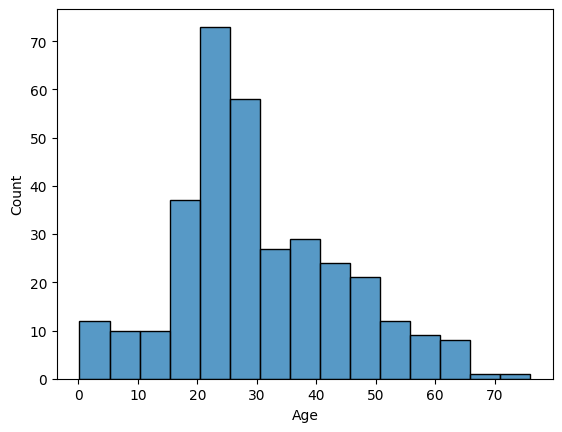

In [26]:
# Checking for skewness of Age category
# The distribution is slightly right-skewed
sns.histplot(df['Age'])

0.4573612871503845


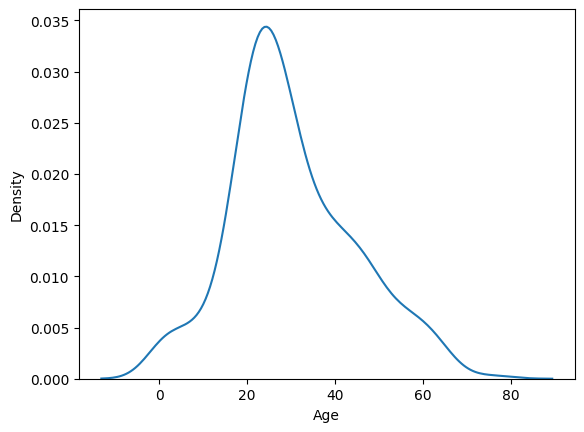

In [30]:
sns.kdeplot(x='Age',data=df)
print (df['Age'].skew())

In [32]:
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

In [34]:
df.dropna(subset=['Fare'], inplace=True)

In [35]:
df.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0


In [36]:
print(df)

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_C  Embarked_Q  \
0         3    1  34.50000      0      0    7.8292           0           1   
1         3    0  47.00000      1      0    7.0000           0           0   
2         2    1  62.00000      0      0    9.6875           0           1   
3         3    1  27.00000      0      0    8.6625           0           0   
4         3    0  22.00000      1      1   12.2875           0           0   
..      ...  ...       ...    ...    ...       ...         ...         ...   
413       3    1  30.27259      0      0    8.0500           0           0   
414       1    0  39.00000      0      0  108.9000           1           0   
415       3    1  38.50000      0      0    7.2500           0           0   
416       3    1  30.27259      0      0    8.0500           0           0   
417       3    1  30.27259      1      1   22.3583           1           0   

     Embarked_S  
0             0  
1             1  
2        

In [38]:
df.to_csv('/cleaned_test.csv',header=True)